In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-prediction-dataset


In [3]:
#copy all dataset files
import shutil
import os

source=path # Use the path returned by kagglehub.dataset_download
destination="/content/drive/MyDrive/pima-diabetes"

# Create the destination directory if it doesn't exist
if not os.path.exists(destination):
    os.makedirs(destination)

for file in os.listdir(source):
    shutil.copy(os.path.join(source,file),destination)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader

torch.manual_seed(42)
np.random.seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
#1-Load & explore the dataset
df=pd.read_csv("/content/drive/MyDrive/pima-diabetes/diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
df.shape #dataset shape

(100000, 9)

In [7]:
df.isnull().sum().sort_values(ascending=False) #how many missing values do we have?

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [8]:
df.dtypes #dataset data types

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


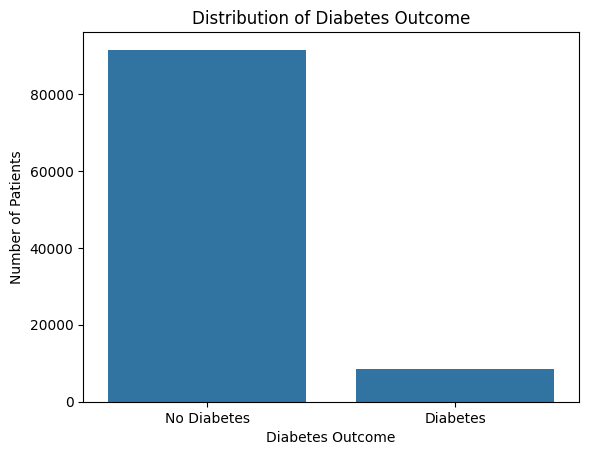

In [10]:
#Let's look at the target's distribution
import seaborn as sns
sns.countplot(x="diabetes", data=df)
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.show()

In [11]:
df['diabetes'].value_counts()#finding how many diabetic and non diabetic people do we have in this dataset?

,count
diabetes,
0,91500
1,8500


In [12]:
df.describe()#summary of the dataset

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


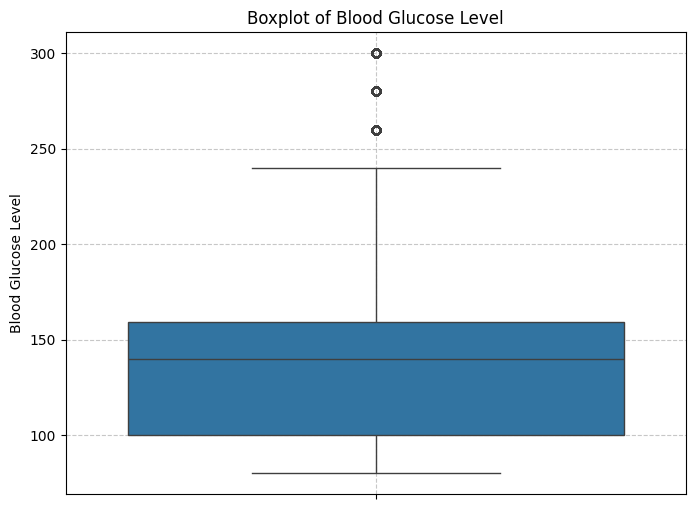

In [13]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['blood_glucose_level'])
plt.title('Boxplot of Blood Glucose Level')
plt.ylabel('Blood Glucose Level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Filtering Outliers using IQR
To filter outliers, we'll calculate the Interquartile Range (IQR) for the blood_glucose_level feature. The IQR is the range between the first quartile (Q1) and the third quartile (Q3). Outliers are typically defined as values that fall outside of 1.5 times the IQR below Q1 or above Q3.

In [14]:
# Calculate Q1, Q3, and IQR for 'blood_glucose_level'
Q1 = df['blood_glucose_level'].quantile(0.25)
Q3 = df['blood_glucose_level'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers (keep values within the bounds)
df_no_outliers = df[(df['blood_glucose_level'] > lower_bound) & (df['blood_glucose_level'] < upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after removing outliers: {df_no_outliers.shape}")

display(df_no_outliers.head())

Original DataFrame shape: (100000, 9)
DataFrame shape after removing outliers: (97962, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


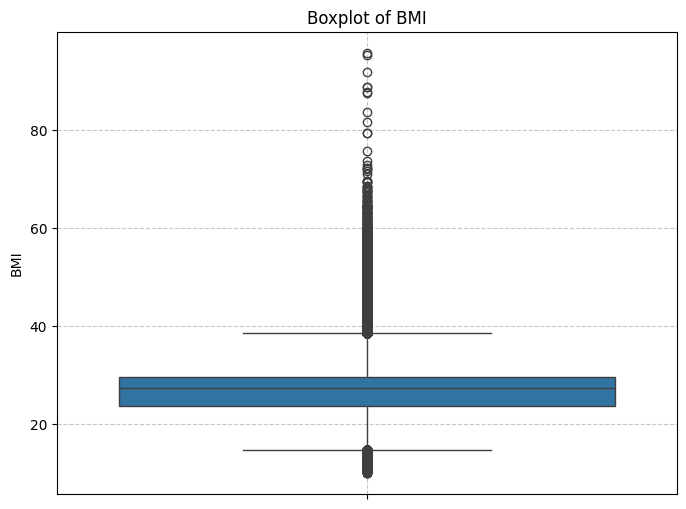

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['bmi'])
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Scaling Categorical Features

I will now process the categorical features. I'll drop the 'gender' column as the 'Other' category might not be useful for prediction and can cause issues. Then, I'll apply one-hot encoding to the 'smoking_history' column to convert it into a numerical format suitable for machine learning models.

In [16]:
# Drop the 'gender' column due to the 'Other' category
df_processed = df_no_outliers.drop(columns=['gender'])

# Apply one-hot encoding to 'smoking_history'
df_processed = pd.get_dummies(df_processed, columns=['smoking_history'], drop_first=True)

print(f"DataFrame shape after processing categorical features: {df_processed.shape}")
display(df_processed.head())

DataFrame shape after processing categorical features: (97962, 12)


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,False,False,False


## Splitting the Dataset into Training, Validation, and Test Sets

To prepare the data for model training and evaluation, I will split the `df_processed` DataFrame into three subsets: training, validation, and test sets. This ensures that the model is trained on one set of data, tuned on another, and finally evaluated on unseen data to assess its generalization performance. I'll use a 70/15/15 split for training, validation, and testing, respectively.

In [17]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_processed.drop('diabetes', axis=1)
y = df_processed['diabetes']

# Split the data into training (70%) and temporary (30%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the temporary data into validation (15%) and test (15%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (68573, 11)
y_train shape: (68573,)
X_val shape: (14694, 11)
y_val shape: (14694,)
X_test shape: (14695, 11)
y_test shape: (14695,)


## Scaling Numerical Features

To ensure that all numerical features contribute equally to the model training and to prevent features with larger values from dominating, I will apply standardization using `StandardScaler` from `sklearn.preprocessing`. This will transform the data to have a mean of 0 and a standard deviation of 1. I'll fit the scaler on the training data (`X_train`) and then transform `X_train`, `X_val`, and `X_test` using this fitted scaler to avoid data leakage.

In [18]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test data using the fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Shape of scaled training data:", X_train_scaled.shape)
print("Shape of scaled validation data:", X_val_scaled.shape)
print("Shape of scaled test data:", X_test_scaled.shape)

# Display a small part of the scaled training data
print("\nFirst 5 rows of scaled training data:")
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Shape of scaled training data: (68573, 11)
Shape of scaled validation data: (14694, 11)
Shape of scaled test data: (14695, 11)

First 5 rows of scaled training data:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0.551969,-0.2775,-0.197366,-0.593901,1.044587,-1.414356,-0.318568,-0.201556,-0.319068,1.360526,-0.261658
1,0.329881,-0.2775,-0.197366,0.256407,0.283632,-0.145414,-0.318568,-0.201556,-0.319068,1.360526,-0.261658
2,-1.535657,-0.2775,-0.197366,0.016069,-1.904113,0.672348,-0.318568,-0.201556,-0.319068,-0.735010,-0.261658
3,-1.313569,-0.2775,-0.197366,-0.814464,-0.477322,0.277566,-0.318568,-0.201556,-0.319068,1.360526,-0.261658
4,-0.425218,-0.2775,-0.197366,0.016069,0.188513,-0.145414,-0.318568,-0.201556,-0.319068,1.360526,-0.261658


## Handling Class Imbalance with SMOTE

The target variable `diabetes` is imbalanced, with a much larger number of non-diabetic cases. To address this, I will use Synthetic Minority Over-sampling Technique (SMOTE) to generate synthetic samples for the minority class (diabetes=1) in the training set. This will help prevent the model from being biased towards the majority class.

It's important to apply SMOTE *after* splitting the data and *after* scaling numerical features to avoid data leakage and ensure fair evaluation.

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Resampled X:", X_train_resampled.shape)
print("Resampled y:", y_train_smote.shape)

print(f"Original training data shape: {X_train_scaled.shape}, {y_train.shape}")
print(f"Resampled training data shape: {X_train_resampled.shape}, {y_train_smote.shape}")

Resampled X: (128100, 11)
Resampled y: (128100,)
Original training data shape: (68573, 11), (68573,)
Resampled training data shape: (128100, 11), (128100,)


## Creating PyTorch Datasets and DataLoaders (Updated for Imbalance)

Now, I will re-create the PyTorch `Dataset` and `DataLoader` objects for the training set using the SMOTE-resampled data. The validation and test sets remain unchanged.

In [20]:
from torch.utils.data import Dataset, DataLoader

class DiabetesDataset(Dataset):
    def __init__(self, X, y):

        # Convert features to NumPy array, then to float32 tensor
        self.X = torch.tensor(
            np.asarray(X, dtype=np.float32),
            dtype=torch.float32
        )

        # Convert target to NumPy array, then to float32 tensor
        # Required for BCEWithLogitsLoss
        self.y = torch.tensor(
            np.asarray(y, dtype=np.float32),
            dtype=torch.float32
        ).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


# Create datasets
train_dataset = DiabetesDataset(
    X_train_resampled,
    y_train_smote
)

val_dataset = DiabetesDataset(
    X_val_scaled,
    y_val
)

test_dataset = DiabetesDataset(
    X_test_scaled,
    y_test
)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


# Check one batch
X_batch, y_batch = next(iter(train_loader))

print("Features shape:", X_batch.shape)
print("Targets shape:", y_batch.shape)
print("Features dtype:", X_batch.dtype)
print("Targets dtype:", y_batch.dtype)

print(f"Number of batches in training loader (resampled): {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")

# Example of one batch from the resampled train_loader
for features, targets in train_loader:
    print("\nExample batch from resampled train_loader:")
    print(f"Features shape: {features.shape}")
    print(f"Targets shape: {targets.shape}")
    break

Features shape: torch.Size([64, 11])
Targets shape: torch.Size([64, 1])
Features dtype: torch.float32
Targets dtype: torch.float32
Number of batches in training loader (resampled): 2002
Number of batches in validation loader: 230
Number of batches in test loader: 230

Example batch from resampled train_loader:
Features shape: torch.Size([64, 11])
Targets shape: torch.Size([64, 1])


In [21]:
from collections import Counter

train_targets = []

for _, y_batch in train_loader:
    train_targets.extend(y_batch.numpy().ravel())

counts = Counter(train_targets)

print("Training class distribution:")
print("No Diabetes:", counts[0.0])
print("Diabetes:", counts[1.0])

Training class distribution:
No Diabetes: 64050
Diabetes: 64050


## Building a Neural Network with PyTorch (Baseline Model)

I will now define a simple feedforward neural network (Multi-Layer Perceptron) using PyTorch's `nn.Module`. The network will consist of several linear layers with ReLU activation functions, and a final output layer with a sigmoid activation function, suitable for binary classification. This will serve as our baseline model.

In [22]:
# Get the input size from the scaled training data
input_size = X_train_scaled.shape[1]

class DiabetesNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create Model 1
model1 = DiabetesNN().to(device)

print(model1)
print("\nDevice:", device)

DiabetesNN(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Device: cuda


## Training the Neural Network (Baseline Model)

Now, I will implement the training loop for the baseline model. This involves:
1.  **Defining Loss Function and Optimizer**: Using Binary Cross-Entropy Loss (`nn.BCELoss`) suitable for binary classification and the Adam optimizer.
2.  **Training Loop**: Iterating over a specified number of epochs.
    *   For each epoch, iterating through the `train_loader` to get mini-batches of data.
    *   Performing a **forward pass** to get predictions.
    *   **Calculating the loss** between predictions and actual targets.
    *   Performing **backpropagation** to compute gradients.
    *   **Updating weights** using the optimizer.
    *   **Resetting gradients** to zero for the next iteration.
3.  **Validation Loop**: After each training epoch, evaluating the model on the `val_loader` to monitor performance and identify potential overfitting. The model will be set to evaluation mode, and gradients will be disabled during this phase.

In [23]:
from sklearn.metrics import accuracy_score, f1_score

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model1.parameters(),
    lr=0.001
)

# Number of epochs
epochs = 20


# Store metrics
train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []


# =========================
# Training Loop
# =========================

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model1.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        logits = model1(X_batch)

        # Calculate loss
        loss = criterion(logits, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # -------------------------
    # Validation
    # -------------------------
    model1.eval()

    running_val_loss = 0.0

    all_val_predictions = []
    all_val_targets = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            logits = model1(X_batch)

            # Validation loss
            loss = criterion(logits, y_batch)

            running_val_loss += loss.item()

            # Convert logits to probabilities
            probabilities = torch.sigmoid(logits)

            # Convert probabilities to 0/1 predictions
            predictions = (probabilities >= 0.5).float()

            all_val_predictions.extend(
                predictions.cpu().numpy().flatten()
            )

            all_val_targets.extend(
                y_batch.cpu().numpy().flatten()
            )


    # -------------------------
    # Validation Metrics
    # -------------------------

    epoch_val_loss = running_val_loss / len(val_loader)

    val_accuracy = accuracy_score(
        all_val_targets,
        all_val_predictions
    )

    val_f1 = f1_score(
        all_val_targets,
        all_val_predictions,
        zero_division=0
    )

    val_losses.append(epoch_val_loss)
    val_accuracies.append(val_accuracy)
    val_f1_scores.append(val_f1)


    # -------------------------
    # Print Results
    # -------------------------

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

Epoch [1/20] | Train Loss: 0.2691 | Val Loss: 0.2777 | Val Accuracy: 0.8616 | Val F1: 0.4654
Epoch [2/20] | Train Loss: 0.2324 | Val Loss: 0.2354 | Val Accuracy: 0.8761 | Val F1: 0.4891
Epoch [3/20] | Train Loss: 0.2193 | Val Loss: 0.2330 | Val Accuracy: 0.8723 | Val F1: 0.4828
Epoch [4/20] | Train Loss: 0.2112 | Val Loss: 0.2127 | Val Accuracy: 0.8776 | Val F1: 0.4899
Epoch [5/20] | Train Loss: 0.2057 | Val Loss: 0.2614 | Val Accuracy: 0.8572 | Val F1: 0.4593
Epoch [6/20] | Train Loss: 0.2018 | Val Loss: 0.2166 | Val Accuracy: 0.8741 | Val F1: 0.4835
Epoch [7/20] | Train Loss: 0.1993 | Val Loss: 0.2097 | Val Accuracy: 0.8802 | Val F1: 0.4932
Epoch [8/20] | Train Loss: 0.1971 | Val Loss: 0.2033 | Val Accuracy: 0.8831 | Val F1: 0.4987
Epoch [9/20] | Train Loss: 0.1959 | Val Loss: 0.2181 | Val Accuracy: 0.8782 | Val F1: 0.4905
Epoch [10/20] | Train Loss: 0.1945 | Val Loss: 0.2102 | Val Accuracy: 0.8809 | Val F1: 0.4936
Epoch [11/20] | Train Loss: 0.1933 | Val Loss: 0.2201 | Val Accuracy:

In [24]:
# Convert X_val to a numeric NumPy array
X_val_array = X_val_scaled.astype("float32")

print(X_val_array.dtype)
print(X_val_array.shape)

float32
(14694, 11)


In [25]:
#Convert to a PyTorch Tensor
X_val_tensor = torch.from_numpy(X_val_array)

print(X_val_tensor.dtype)
print(X_val_tensor.shape)

torch.float32
torch.Size([14694, 11])


In [26]:
# Get the device of the model
device = next(model1.parameters()).device
print("Model device:", device)

# Validation features: X_val_scaled is already a NumPy array
X_val_tensor = torch.tensor(
    X_val_scaled.astype("float32"),
    dtype=torch.float32,
    device=device
)

# Validation targets: y_val is a pandas Series
y_val_tensor = torch.tensor(
    y_val.to_numpy(dtype="float32"),
    dtype=torch.float32,
    device=device
).view(-1, 1)

print("Validation features shape:", X_val_tensor.shape)
print("Validation targets shape:", y_val_tensor.shape)
print("Validation device:", X_val_tensor.device)

Model device: cuda:0
Validation features shape: torch.Size([14694, 11])
Validation targets shape: torch.Size([14694, 1])
Validation device: cuda:0


Evaluating the baseline model on validation set

In [27]:
# =========================
# Model 1 - Validation Evaluation
# =========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model1.eval()

all_val_predictions = []
all_val_probabilities = []
all_val_targets = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(device)

        # Raw logits
        logits = model1(X_batch)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(logits)

        # Convert probabilities to predictions
        predictions = (probabilities >= 0.5).float()

        all_val_probabilities.extend(
            probabilities.cpu().numpy().flatten()
        )

        all_val_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

        all_val_targets.extend(
            y_batch.numpy().flatten()
        )


# =========================
# Calculate Metrics
# =========================

val_accuracy = accuracy_score(
    all_val_targets,
    all_val_predictions
)

val_precision = precision_score(
    all_val_targets,
    all_val_predictions,
    zero_division=0
)

val_recall = recall_score(
    all_val_targets,
    all_val_predictions,
    zero_division=0
)

val_f1 = f1_score(
    all_val_targets,
    all_val_predictions,
    zero_division=0
)

# =========================
# Display Results
# =========================

print("===== Model 1 Validation Results =====")

print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

===== Model 1 Validation Results =====
Accuracy : 0.8871
Precision: 0.3552
Recall   : 0.8731
F1 Score : 0.5049


## Experiment & Model Improvement

Now that we have a baseline model, let's explore ways to improve its performance. We will compare our baseline model with an improved version that incorporates some common neural network improvements.

### Improved Model Architecture

For the improved model, I will:
- Add more layers and neurons to increase model capacity.
- Introduce `Dropout` layers to prevent overfitting.
- The model will use `nn.Linear` layers with `ReLU` activation functions, and a final `Sigmoid` for binary classification.

In [28]:
class DiabetesNN_Updated(nn.Module):
    def __init__(self):
        super(DiabetesNN_Updated, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


model2 = DiabetesNN_Updated().to(device)

print(model2)
print("Model device:", next(model2.parameters()).device)

DiabetesNN_Updated(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)
Model device: cuda:0


In [29]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model2.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

Training the new model

In [30]:
num_epochs = 20

for epoch in range(num_epochs):

    # =========================
    # Training
    # =========================
    model2.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).float()

        optimizer.zero_grad()

        logits = model2(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # =========================
    # Validation
    # =========================
    model2.eval()

    val_loss = 0.0
    all_val_preds = []
    all_val_targets = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).float()

            logits = model2(X_batch)

            loss = criterion(logits, y_batch)
            val_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            all_val_preds.extend(preds.cpu().numpy().ravel())
            all_val_targets.extend(y_batch.cpu().numpy().ravel())

    avg_val_loss = val_loss / len(val_loader)

    val_accuracy = accuracy_score(
        all_val_targets,
        all_val_preds
    )

    val_f1 = f1_score(
        all_val_targets,
        all_val_preds,
        zero_division=0
    )

    # =========================
    # Print results
    # =========================
    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}, "
        f"Val Accuracy: {val_accuracy:.4f}, "
        f"Val F1-Score: {val_f1:.4f}"
    )

Epoch 1/20, Train Loss: 0.3120, Val Loss: 0.2767, Val Accuracy: 0.8596, Val F1-Score: 0.4587
Epoch 2/20, Train Loss: 0.2562, Val Loss: 0.2561, Val Accuracy: 0.8691, Val F1-Score: 0.4767
Epoch 3/20, Train Loss: 0.2424, Val Loss: 0.2272, Val Accuracy: 0.8773, Val F1-Score: 0.4902
Epoch 4/20, Train Loss: 0.2329, Val Loss: 0.2184, Val Accuracy: 0.8777, Val F1-Score: 0.4914
Epoch 5/20, Train Loss: 0.2258, Val Loss: 0.2142, Val Accuracy: 0.8792, Val F1-Score: 0.4962
Epoch 6/20, Train Loss: 0.2206, Val Loss: 0.2184, Val Accuracy: 0.8738, Val F1-Score: 0.4871
Epoch 7/20, Train Loss: 0.2162, Val Loss: 0.2259, Val Accuracy: 0.8716, Val F1-Score: 0.4836
Epoch 8/20, Train Loss: 0.2116, Val Loss: 0.2054, Val Accuracy: 0.8820, Val F1-Score: 0.5020
Epoch 9/20, Train Loss: 0.2094, Val Loss: 0.2231, Val Accuracy: 0.8714, Val F1-Score: 0.4818
Epoch 10/20, Train Loss: 0.2087, Val Loss: 0.2219, Val Accuracy: 0.8723, Val F1-Score: 0.4853
Epoch 11/20, Train Loss: 0.2067, Val Loss: 0.2037, Val Accuracy: 0.87

Evaluate the updated model on validation set

In [31]:
# =========================
# Model 2 - Validation Evaluation
# =========================
model2.eval()

all_val_predictions2 = []
all_val_probabilities2 = []
all_val_targets2 = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(device)

        # Raw logits
        logits = model2(X_batch)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(logits)

        # Convert probabilities to predictions
        predictions = (probabilities >= 0.5).float()

        all_val_probabilities2.extend(
            probabilities.cpu().numpy().flatten()
        )

        all_val_predictions2.extend(
            predictions.cpu().numpy().flatten()
        )

        all_val_targets2.extend(
            y_batch.numpy().flatten()
        )


# =========================
# Calculate Metrics
# =========================

val2_accuracy = accuracy_score(
    all_val_targets2,
    all_val_predictions2
)

val2_precision = precision_score(
    all_val_targets2,
    all_val_predictions2,
    zero_division=0
)

val2_recall = recall_score(
    all_val_targets2,
    all_val_predictions2,
    zero_division=0
)

val2_f1 = f1_score(
    all_val_targets2,
    all_val_predictions2,
    zero_division=0
)

# =========================
# Display Results
# =========================

print("===== Model 2 Validation Results =====")

print(f"Accuracy : {val2_accuracy:.4f}")
print(f"Precision: {val2_precision:.4f}")
print(f"Recall   : {val2_recall:.4f}")
print(f"F1 Score : {val2_f1:.4f}")

===== Model 2 Validation Results =====
Accuracy : 0.8810
Precision: 0.3452
Recall   : 0.8978
F1 Score : 0.4987


Comparing the 2 models

In [32]:
metrics_df = pd.DataFrame({
    "Model": ["Model 1", "Model 2"],
    "Accuracy": [
        val_accuracy,      # Model 1
        val2_accuracy      # Model 2
    ],
    "Precision": [
        val_precision,     # Model 1
        val2_precision     # Model 2
    ],
    "Recall": [
        val_recall,        # Model 1
        val2_recall        # Model 2
    ],
    "F1 Score": [
        val_f1,            # Model 1
        val2_f1            # Model 2
    ]
})

metrics_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Model 1,0.881,0.3552,0.8731,0.4987
1,Model 2,0.881,0.3452,0.8978,0.4987


We will choose Model 2 because the main reason is recall.

-Model 2 correctly identifies 89.78% of the actual diabetes cases.

-Model 1 identifies 87.31%.

-Their accuracy and F1 score are identical.

-Model 1 has slightly better precision, but the difference is relatively small.

For a diabetes screening/classification project, missing an actual diabetes case (a false negative) can be more concerning than incorrectly flagging someone who does not have diabetes (a false positive). Therefore, the higher recall of Model 2 is an important consideration.

Final decision

Final model: Model 2

Model 2 was selected as the final model because it achieved the same accuracy and F1 score as Model 1 while obtaining a higher recall of 89.78%, allowing it to identify a greater proportion of actual diabetes cases on the validation set.

Let's visualize the confusion matrices for the models

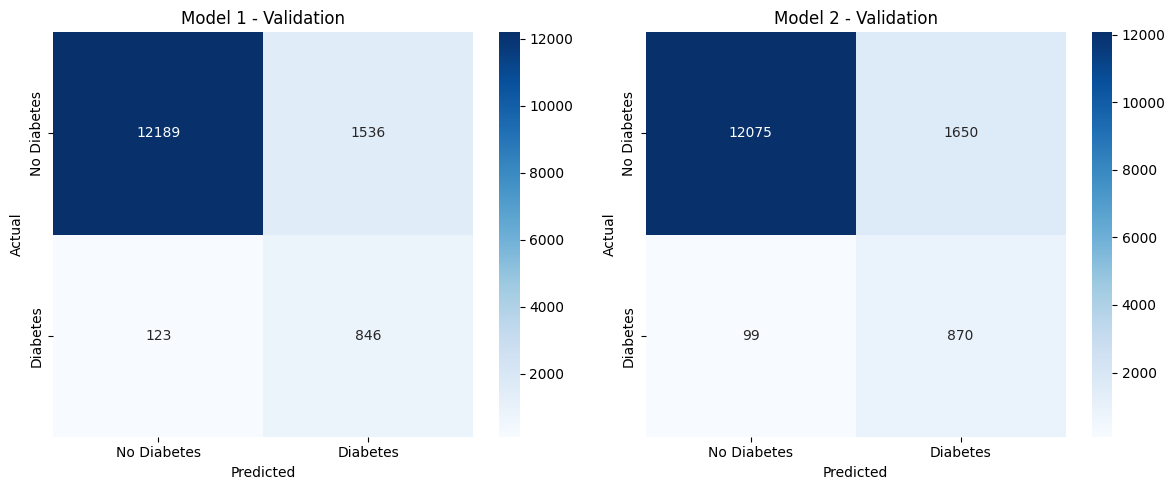

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrices
cm1 = confusion_matrix(all_val_targets, all_val_predictions)
cm2 = confusion_matrix(all_val_targets, all_val_preds)

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Model 1
sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"],
    ax=axes[0]
)

axes[0].set_title("Model 1 - Validation")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Model 2
sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"],
    ax=axes[1]
)

axes[1].set_title("Model 2 - Validation")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Evaluating Model 2 on test set

In [34]:
# Put the final model in evaluation mode
model2.eval()

all_test_predictions = []
all_test_targets = []
all_test_probabilities = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        # Raw model output
        logits = model2(X_batch)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(logits)

        # Convert probabilities to class predictions
        predictions = (probabilities >= 0.5).float()

        all_test_probabilities.extend(
            probabilities.cpu().numpy().flatten()
        )

        all_test_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

        all_test_targets.extend(
            y_batch.numpy().flatten()
        )


# Calculate metrics
test_accuracy = accuracy_score(
    all_test_targets,
    all_test_predictions
)

test_f1 = f1_score(
    all_test_targets,
    all_test_predictions,
    zero_division=0
)

test_cm = confusion_matrix(
    all_test_targets,
    all_test_predictions
)


print("FINAL TEST RESULTS")
print("=" * 40)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"F1-score : {test_f1:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

print("\nClassification Report:")
print(
    classification_report(
        all_test_targets,
        all_test_predictions,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)

FINAL TEST RESULTS
Accuracy : 0.8824
F1-score : 0.5054

Confusion Matrix:
[[12084  1641]
 [   87   883]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.99      0.88      0.93     13725
    Diabetes       0.35      0.91      0.51       970

    accuracy                           0.88     14695
   macro avg       0.67      0.90      0.72     14695
weighted avg       0.95      0.88      0.91     14695



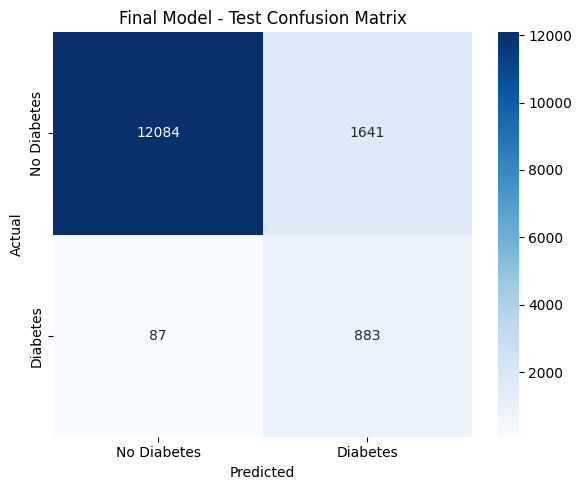

In [35]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Final Model - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Save & Reload Your Model

To ensure our trained model and preprocessing steps can be reused, we will save the model's weights and the `StandardScaler` object. Then, we will reload them to confirm that predictions remain consistent, demonstrating that the saving and reloading process works correctly.

In [36]:
import joblib

# Save model weights
torch.save(
    model2.state_dict(),
    "diabetes_model2.pth"
)

# Save scaler
joblib.dump(
    scaler,
    "diabetes_scaler.pkl"
)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


Reload the Model

In [37]:
model2_loaded = DiabetesNN_Updated().to(device)

model2_loaded.load_state_dict(
    torch.load(
        "diabetes_model2.pth",
        map_location=device
    )
)

model2_loaded.eval()

print("Model reloaded successfully.")

Model reloaded successfully.


Reload the Scaler

In [38]:
scaler_loaded = joblib.load(
    "diabetes_scaler.pkl"
)

print("Scaler reloaded successfully.")

Scaler reloaded successfully.


Confirm predictions remain consistent

In [39]:
model2.eval()
model2_loaded.eval()

with torch.no_grad():

    X_sample = test_dataset.X[:20].to(device)

    # Original model predictions
    original_logits = model2(X_sample)
    original_probabilities = torch.sigmoid(original_logits)

    # Reloaded model predictions
    loaded_logits = model2_loaded(X_sample)
    loaded_probabilities = torch.sigmoid(loaded_logits)


# Compare predictions
difference = torch.max(
    torch.abs(
        original_probabilities - loaded_probabilities
    )
).item()

print(f"Maximum prediction difference: {difference:.10f}")

if difference < 1e-6:
    print("Predictions are consistent after reloading.")
else:
    print("Predictions are different.")

Maximum prediction difference: 0.0000000000
Predictions are consistent after reloading.
